# Parameter-dependency of Markov Chain Model for Tomimoto and Satake 2026
Following is the code for evaluating parameter dependency of inter-branch SNVs.

##### Packages information used in this code:  
numpy==2.0.1  
pyabc==0.12.15  
scipy==1.15.3  
seaborn==0.13.2  
matplotlib==3.10.0 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import math
from scipy.stats import binom # structured elongation
from scipy.stats import hypergeom # stochastic elongation

import itertools # pattern of mutation expansion
import copy

In [2]:
# Elongation

def el_str_M(num_stem, mut_rate): # structured elongation transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):
            
            tr_matrix[i, j] = binom.pmf(j-i, num_stem-i, mut_rate)

    return tr_matrix

def el_sto_M(num_stem, mut_rate): # stochastic elongation transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):
            
            #print(sum([m for m in range(2*(num_stem-i)+1)]))
            tr_matrix[i, j] = sum([ binom.pmf(m, 2*(num_stem-i), mut_rate)
                                   *hypergeom.pmf(j, 2*num_stem, 2*i+m, num_stem) for m in range(2*(num_stem-i)+1)])

    return tr_matrix

In [3]:
# Branching

def br_wf_M(num_stem): # wright-fisher Branching transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):

            tr_matrix[i, j] = binom.pmf(j, num_stem, i/num_stem)

    return tr_matrix

def br_sc_M(num_stem): # single cell Branching transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):

            if j == 0:
                tr_matrix[i, j] = (num_stem-i)/num_stem
            elif j == num_stem:
                tr_matrix[i, j] = i/num_stem
            else:
                tr_matrix[i, j] = 0

    return tr_matrix

In [4]:
def state_V(num_stem): # state vector
    
    stateVector = np.zeros(num_stem+1, dtype=float) # state vectore
    stateVector[0] = 1
    
    return stateVector

def mat_pw(mat_, t_): # power of matrix
    
    return np.linalg.matrix_power(mat_, t_)

def initial_state(num_stem, i_): # state vector
    
    stateVector = np.zeros(num_stem+1, dtype=float) # state vectore
    stateVector[i_] = 1
    
    return stateVector

def inter_branch_f(mat_i, mat_j): # average distance 0325
    
    num_stem = len(mat_i)-1
    
    tes1 = mat_i
    tes2 = mat_j

    tes1_list = []
    tes2_list = []
    
    for i in range(num_stem+1):
        
        tes1_v = initial_state(num_stem, i)@tes1
        tes2_v = initial_state(num_stem, i)@tes2
        
        mean_1 = np.sum([kct*k for kct, k in enumerate(tes1_v)]) # mean of the state vector
        mean_2 = np.sum([kct*k for kct, k in enumerate(tes2_v)]) # --

        tes1_list.append(mean_1)
        tes2_list.append(mean_2)

    tes_list = []
    
    for j in range(num_stem+1):
    
        tes_list.append( tes1_list[j]/num_stem *(1-tes2_list[j]/num_stem) + (1-tes1_list[j]/num_stem)*tes2_list[j]/num_stem )
    
    return np.array(tes_list)


# def inter_branch_f(mat_i, mat_j):
    
#     one_v = np.ones(len(mat_i))
#     result_ = (one_v - mat_i[0])*mat_j[0] + mat_i[0]*(one_v - mat_j[0]) # mutated(i) * non-mutated(j) + non-mutated(i) * mutated(j)
    
#     return result_

In [7]:
# function: inter-branch mutation by Markov chain

def ibm_Markov(num_stem, mu_, div_, dyn_, brlist_): # 230222, 231105, 240208 
    """　Func for Exp. of Inter-branch mutations by Markov chain
    Args:
        num_stem    (int): Num of stem cells in meristem.
        mu_       (float): Rate of mutation per cell per meter
        div_      (float): Number of cell divisions per meter
        dyn_        (int): Dynamics of stem cells (1-> stru+unbias, 2-> stru+bias, 3-> stoc+unbias, 4-> stoc+bias)
        brlist_ (ndarray): List of branch length
    
    Return:
        [z_Flat, d_Flat, api_Flat] (list): Exp. of inter-branch mutation, Distance between branches, Apical states
    
    Note:
    """
    
    # given parameters
    numBranch = 7
    br_ID = ['11','10','21','20','31','30','40']

    µ_ = mu_ /div_

    s0_0 = round(brlist_[0] *div_)
    s0_1 = round(brlist_[1] *div_)
    s0_2 = round(brlist_[2] *div_)
    s0_3 = round(brlist_[3] *div_)

    b10_0 = round(brlist_[4] *div_)
    b10_1 = round(brlist_[5] *div_) 
    b11   = round(brlist_[6] *div_)

    b20_0 = round(brlist_[7] *div_)
    b20_1 = round(brlist_[8] *div_)
    b21   = round(brlist_[9] *div_)

    b30_0 = round(brlist_[10] *div_)
    b30_1 = round(brlist_[11] *div_)
    b31   = round(brlist_[12] *div_)
    
    brTimeMatrix = np.array([[0, b10_1+b11, b11+b10_0+s0_1+b20_0+b21, b11+b10_0+s0_1+b20_0+b20_1, b11+b10_0+s0_1+s0_2+b30_0+b31, b11+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b11],
                         [0,0, b10_1+b10_0+s0_1+b20_0+b21, b10_1+b10_0+s0_1+b20_0+b20_1, b10_1+b10_0+s0_1+s0_2+b30_0+b31, b10_1+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b10_1],
                         [0,0,0, b21+b20_1, b21+b20_0+s0_2+b30_0+b31, b21+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b21], 
                         [0,0,0,0, b20_1+b20_0+s0_2+b30_0+b31, b20_1+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b20_1], 
                         [0,0,0,0,0, b30_1+b31, s0_3+b30_0+b31],
                         [0,0,0,0,0,0, s0_3+b30_0+b30_1], 
                         [0,0,0,0,0,0,0]])

    #brTimeSet = sorted(set(brTimeMatrix.flatten())) # Set of lenght in order

    for kcut,k in enumerate(brTimeMatrix):
        for lcut,l in enumerate(brTimeMatrix):
            if kcut > lcut:
                brTimeMatrix[kcut][lcut]= l[kcut]

    # apical(0) non-apical(1) matrix
    api_M = np.array([[0, 0, 1, 1, 1, 1, 0],
                      [0, 0, 1, 1, 1, 1, 0],
                      [1, 1, 0, 0, 1, 1, 0],
                      [1, 1, 0, 0, 1, 1, 0],
                      [1, 1, 1, 1, 0, 0, 0],
                      [1, 1, 1, 1, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0]])
    
    # caululation of matrix ----------------------------------------------------------

    # transition matrix
    st_V = state_V(num_stem)

    if dyn_ == 1:
        el_Mat = el_str_M(num_stem, µ_) # structured
        br_Mat = br_wf_M(num_stem) # wright-fisher
        
    elif dyn_ == 2:
        el_Mat = el_str_M(num_stem, µ_) # structured
        br_Mat = br_sc_M(num_stem) # single cell
        
    elif dyn_ == 3:
        el_Mat = el_sto_M(num_stem, µ_) # stochastic
        br_Mat = br_wf_M(num_stem) # wright-fisher
        
    elif dyn_ == 4:
        el_Mat = el_sto_M(num_stem, µ_) # stochastic
        br_Mat = br_sc_M(num_stem) # single cell
    
    else:
        print("dyn_ is not defined")

    # matrix calculation -------------------------------------------------------------
    st_V_s0 = st_V @ mat_pw(el_Mat, s0_0)

    st_V_b10_0 = st_V_s0 @ br_Mat @ mat_pw(el_Mat, b10_0)
    st_V_b11 =  st_V_b10_0 @ br_Mat @ mat_pw(el_Mat, b11)
    st_V_b10 = st_V_b10_0 @ br_Mat @ mat_pw(el_Mat, b10_1) # 240208

    st_V_s1 = st_V_s0 @ br_Mat @ mat_pw(el_Mat, s0_1) # 240208

    st_V_b20_0 = st_V_s1 @ br_Mat @ mat_pw(el_Mat, b20_0)
    st_V_b21 = st_V_b20_0 @ br_Mat @ mat_pw(el_Mat, b21)
    st_V_b20 = st_V_b20_0 @ br_Mat @ mat_pw(el_Mat, b20_1) #240208

    st_V_s2 = st_V_s1 @ mat_pw(el_Mat, s0_2) #230222

    st_V_b30_0 = st_V_s2 @ br_Mat @ mat_pw(el_Mat, b30_0)
    st_V_b31 = st_V_b30_0 @ br_Mat @ mat_pw(el_Mat, b31)
    st_V_b30 = st_V_b30_0 @ br_Mat @ mat_pw(el_Mat, b30_1) #230208

    st_V_b40 = st_V_s2 @ br_Mat @ mat_pw(el_Mat, s0_3) #230208

    # transitions after froking --------------------------------------------------------
    
    # branch 1 to
    af_11_10 = inter_branch_f(
        br_Mat @ mat_pw(el_Mat, b11), 
        br_Mat @ mat_pw(el_Mat, b10_1) ) #240208

    af_11_21 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21) ) #240208

    af_11_20 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1) ) #240208

    af_11_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) ) #240208

    af_11_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) ) #240208

    af_11_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) ) #240208


    af_10_21 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1), #240208
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21) ) #240208

    af_10_20 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1), #240208
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1) ) #240208

    af_10_31 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1), #240208
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) ) #240208

    af_10_30 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1), #240208
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) ) #240208

    af_10_40 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1), #240208
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) ) #240208

    # branch 2 to
    af_21_20 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b21),
        mat_pw(el_Mat, b20_1) )

    af_21_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) ) #240208

    af_21_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) ) #240208

    af_21_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) ) #240208


    af_20_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1), #240208
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) )

    af_20_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1), #240208
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) ) #240208

    af_20_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1), #240208
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) ) #240208

    # branch 3 to
    af_31_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b31),
        br_Mat@mat_pw(el_Mat, b30_1) ) #240208

    af_31_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31),
        br_Mat@mat_pw(el_Mat, s0_3) ) #240208


    af_30_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1),  #240208
        br_Mat@mat_pw(el_Mat, s0_3) ) #240208

    y_M = np.array( # 11, 10, 21, 20, 31, 30, 40 : total prob.
            [[0, np.sum(af_11_10*st_V_b10_0), np.sum(af_11_21*st_V_s0), np.sum(af_11_20*st_V_s0), np.sum(af_11_31*st_V_s0), np.sum(af_11_30*st_V_s0), np.sum(af_11_40*st_V_s0)],
             [0, 0,  np.sum(af_10_21*st_V_s0), np.sum(af_10_20*st_V_s0), np.sum(af_10_31*st_V_s0), np.sum(af_10_30*st_V_s0),  np.sum(af_10_40*st_V_s0)],   
             [0, 0, 0, np.sum(af_21_20*st_V_b20_0), np.sum(af_21_31*st_V_s1), np.sum(af_21_30*st_V_s1), np.sum(af_21_40*st_V_s1)],
             [0, 0, 0, 0, np.sum(af_20_31*st_V_s1), np.sum(af_20_30*st_V_s1), np.sum(af_20_40*st_V_s1)],
             [0, 0, 0, 0, 0, np.sum(af_31_30*st_V_b30_0), np.sum(af_31_40*st_V_s2)],
             [0, 0, 0, 0, 0, 0, np.sum(af_30_40*st_V_s2)],
             [0, 0, 0, 0, 0, 0, 0]])

    z_Flat = []
    d_Flat = []
    api_Flat = []

    for k in range(numBranch):
        for l in range(numBranch):
            
            if k < l:
                z_Flat.append(y_M[k][l]) # not multipled by GenSize
                d_Flat.append(brTimeMatrix[k][l]/div_)
                api_Flat.append(api_M[k][l])

    z_Flat = np.array(z_Flat).flatten()
    d_Flat = np.array(d_Flat).flatten()
    api_Flat = np.array(api_Flat).flatten()
    
    return [z_Flat, d_Flat, api_Flat] # inter-branch mutations, distance between branches, apical states

In [8]:
numBranch = 7
br_ID = ['11','10','21','20','31','30','40']

# branch length

br_len_S1 = [21.79, 8, 10, 11.75, 15, 14.18, 4.74, 11.3, 8.9, 8.1, 2.05, 3.2, 2.9]
br_len_S2 = [22.2, 3.3, 3.6, 7.5, 4.1, 9.25, 9.1, 6.8, 3.6, 3.3, 5.35, 2.7, 2.4]
br_len_F1 = [23.71, 4.4, 6.4, 13.1, 6.35, 9.65, 4.8, 5.4, 3.1, 2.75, 6.05, 1.5, 1.4]
br_len_F2 = [25.27, 2.1, 3.8, 8.9, 1.1, 8.2, 5.8, 10.4, 2.4, 2.4, 6.45, 2.8, 3.3]


# Data: inter-branch mutations

mut_M_S1 = np.array( [[  0, 252, 220, 212, 216, 216, 236],
                      [252,   0, 363, 355, 359, 359, 379],
                      [220, 363,   0, 122, 234, 234, 254],
                      [212, 355, 122,   0, 226, 226, 246],
                      [216, 359, 234, 226,   0,  66, 124],
                      [216, 359, 234, 226,  66,   0, 126],
                      [236, 379, 254, 246, 124, 126,   0]] )/388801756/2

mut_M_S2 = np.array( [[ 0,  36,  76,  75,  62,  62,  67],
                      [36,   0,  76,  75,  62,  62,  67],
                      [76,  76,   0,  27,  74,  74,  79],
                      [75,  75,  27,   0,  73,  73,  78],
                      [62,  62,  74,  73,   0,  20,  57],
                      [62,  62,  74,  73,  20,   0,  57],
                      [67,  67,  79,  78,  57,  57,   0]] )/320739335/2

mut_M_F1 = np.array( [[ 0, 17, 32, 35, 31, 28, 29],
                      [17,  0, 34, 37, 33, 30, 31],
                      [32, 34,  0, 13, 31, 28, 29],
                      [35, 37, 13,  0, 34, 31, 32],
                      [31, 33, 31, 34,  0,  7, 20],
                      [28, 30, 28, 31,  7,  0, 17],
                      [29, 31, 29, 32, 20, 17,  0]] )/323729573/2

mut_M_F2 = np.array([ [ 0, 29, 24, 26, 28, 29, 34],
                      [29,  0, 13, 15, 17, 18, 23],
                      [24, 13,  0,  6, 12, 13, 18],
                      [26, 15,  6,  0, 14, 15, 20],
                      [28, 17, 12, 14,  0,  7, 18],
                      [29, 18, 13, 15,  7,  0, 19],
                      [34, 23, 18, 20, 18, 19,  0]])/263488812/2


mut_S1_Flat = []; mut_S2_Flat = []; mut_F1_Flat = []; mut_F2_Flat = []

for k in range(numBranch):
    for l in range(numBranch):
        
        if k < l:
            mut_S1_Flat.append(mut_M_S1[k][l])
            mut_S2_Flat.append(mut_M_S2[k][l])
            mut_F1_Flat.append(mut_M_F1[k][l])
            mut_F2_Flat.append(mut_M_F2[k][l])

mut_S1_Flat = np.array(mut_S1_Flat).flatten()
mut_S2_Flat = np.array(mut_S2_Flat).flatten()
mut_F1_Flat = np.array(mut_F1_Flat).flatten()
mut_F2_Flat = np.array(mut_F2_Flat).flatten()

In [9]:
#null regression

def reg_0(x, y):
    a = np.dot(x, y)/ (x ** 2).sum()
    return a

### Parameter dependency

In [10]:
para_L = []

µs_max_iter = 80
µf_max_iter = 20

for n_stem in [0]:
    for µ_s1 in range(1, µs_max_iter+1, 3):
        for µ_s2 in range(1, µs_max_iter+1, 3):
            for µ_f1 in range(1, µf_max_iter+1, 3):
                for r_ in range(1,34, 4):
                    for dy_ in range(1,4+1):
                        para_L.append([n_stem, 0.1*µ_s1*10**(-9), 0.1*µ_s2*10**(-9), 0.1*µ_f1*10**(-9), 0.1*µ_f1*10**(-9), r_, dy_])
print(len(para_L))

183708


In [11]:
# focal parameter lists

num_stList = [i for i in range(1, 35, 8)]
mutList = [i*0.1*10**(-9) for i in range(1, 80, 16)]
divList = [i for i in range(1,34, 8)]
dynList = [i for i in range(1,4+1)]

print(num_stList, mutList, divList)

[1, 9, 17, 25, 33] [1.0000000000000002e-10, 1.7000000000000003e-09, 3.3000000000000006e-09, 4.900000000000001e-09, 6.5e-09] [1, 9, 17, 25, 33]


In [12]:
num_stList = [1, 5, 15, 25, 35]
mutList = [1.0e-10, 1.7e-09, 3.3e-09, 4.9e-09, 8.0e-09]
divList = [1, 3, 13, 23, 33]

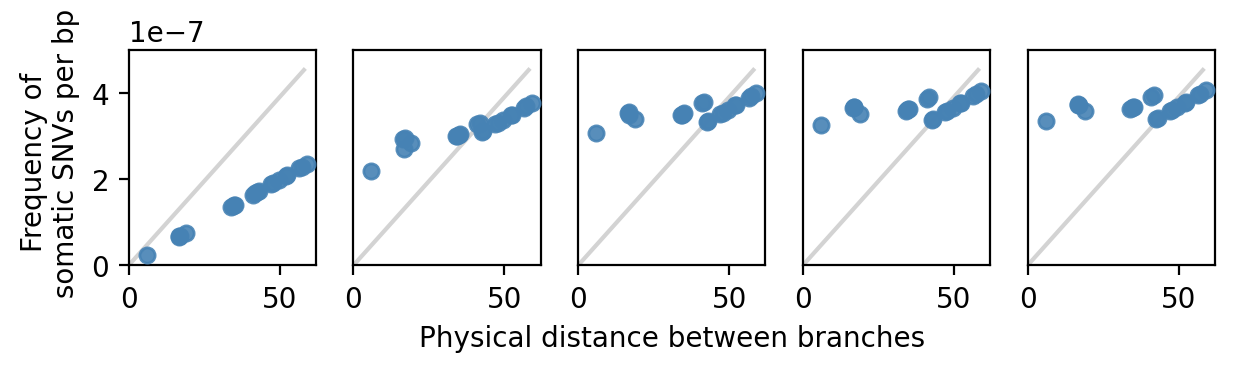

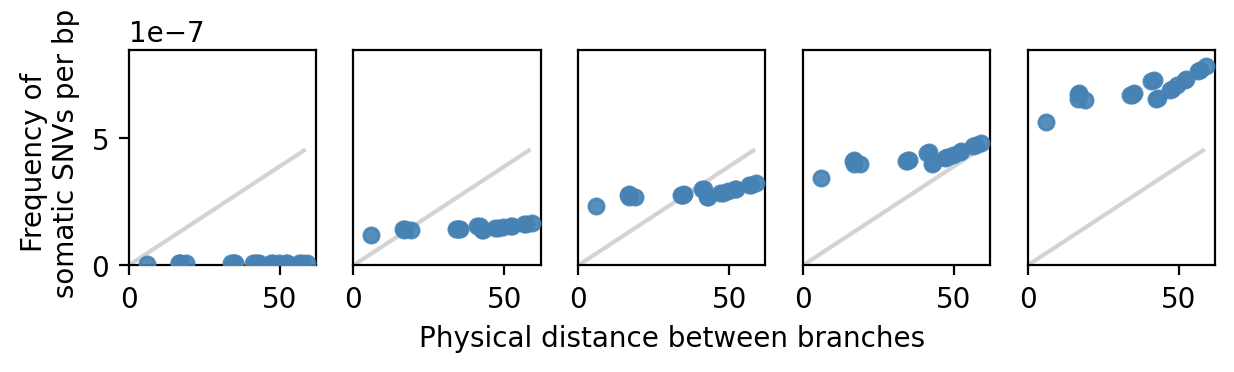

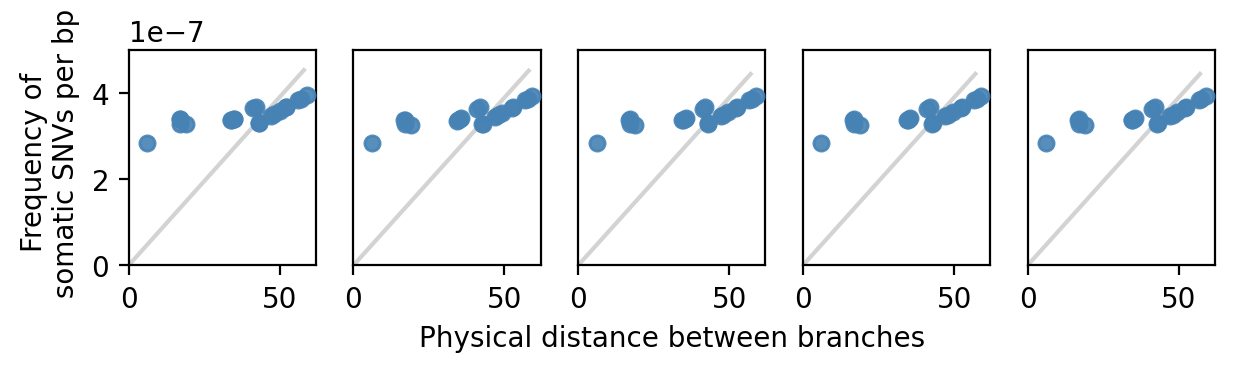

In [27]:
dyn = 1 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
    
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        if ct_p==1:
            plt.xlim(0,); plt.ylim(0,8.5*10**(-7) )
        else:
            plt.xlim(0,); plt.ylim(0,5*10**(-7) )
            
    plt.show()

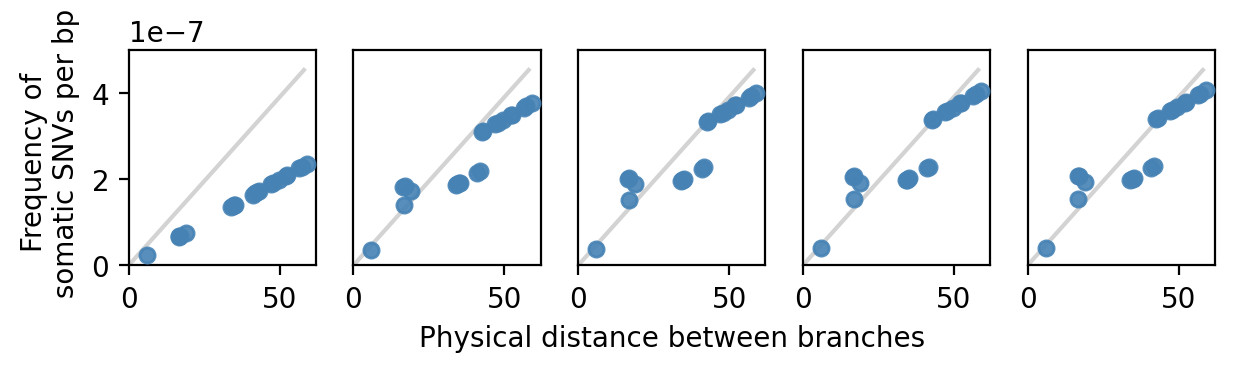

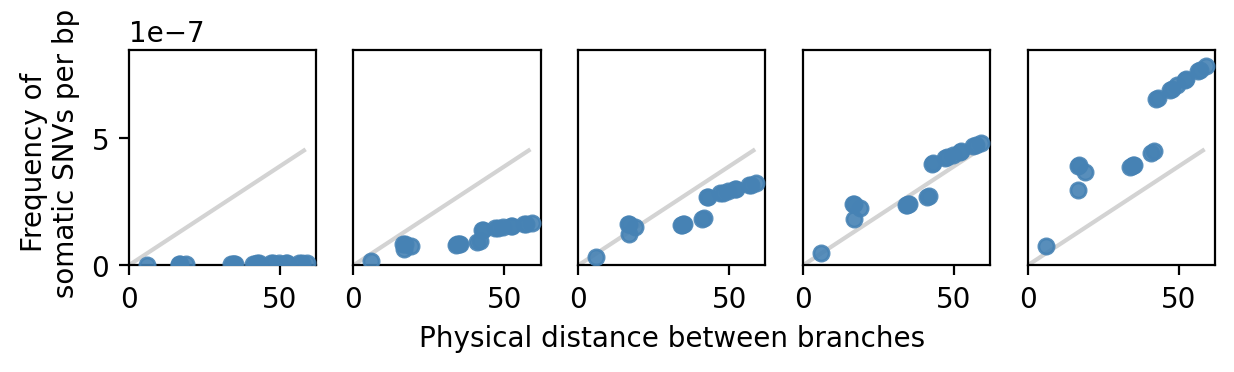

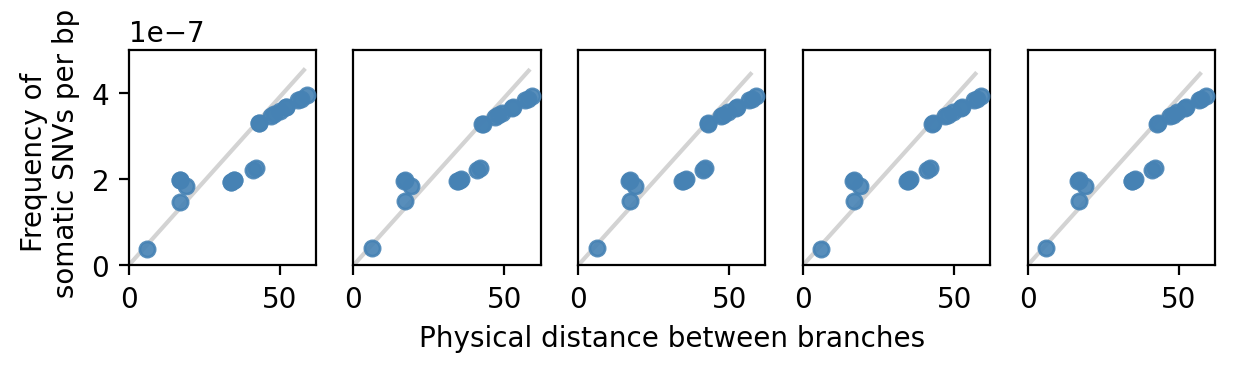

In [26]:
dyn = 2 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
    
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        if ct_p==1:
            plt.xlim(0,); plt.ylim(0,8.5*10**(-7) )
        else:
            plt.xlim(0,); plt.ylim(0,5*10**(-7) )
            
    plt.show()

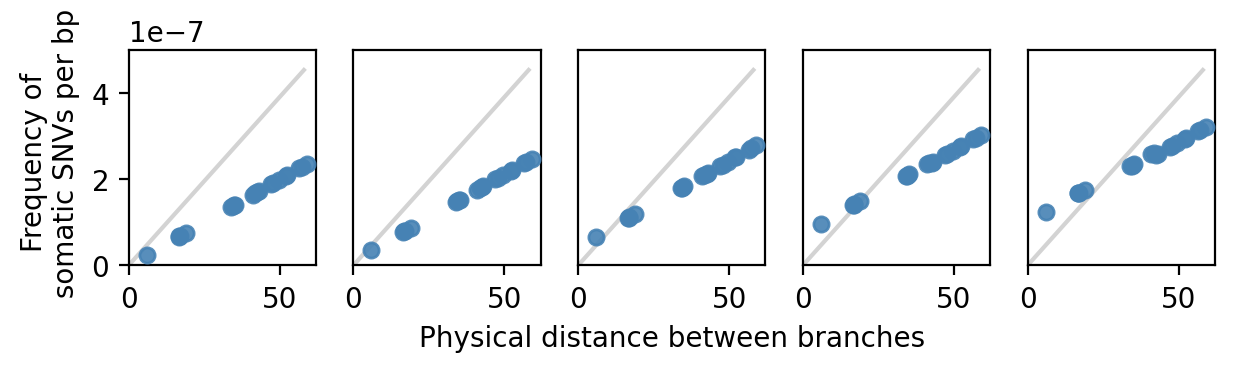

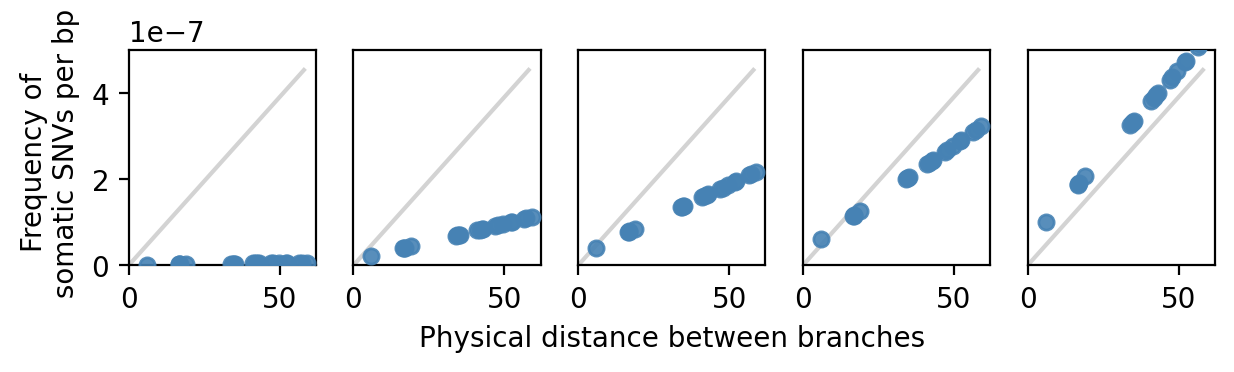

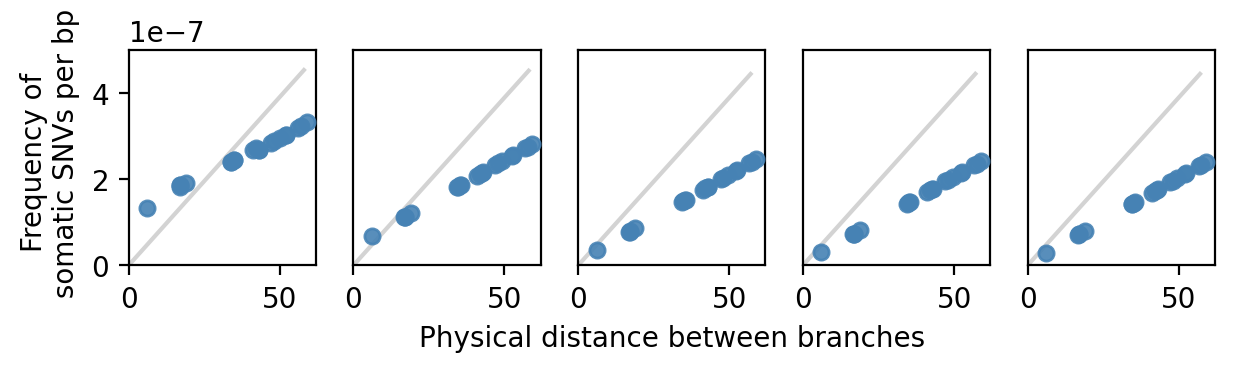

In [24]:
dyn = 3 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
    
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,5*10**(-7) )
            
    plt.show()

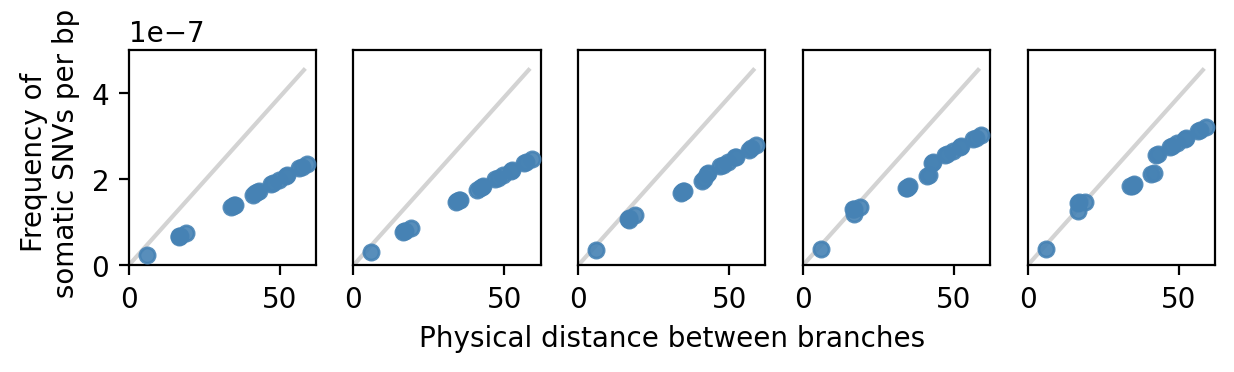

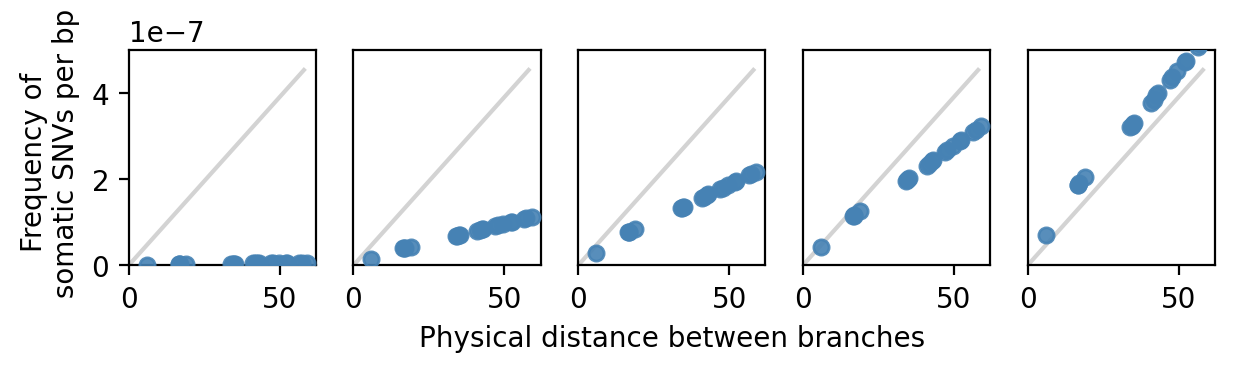

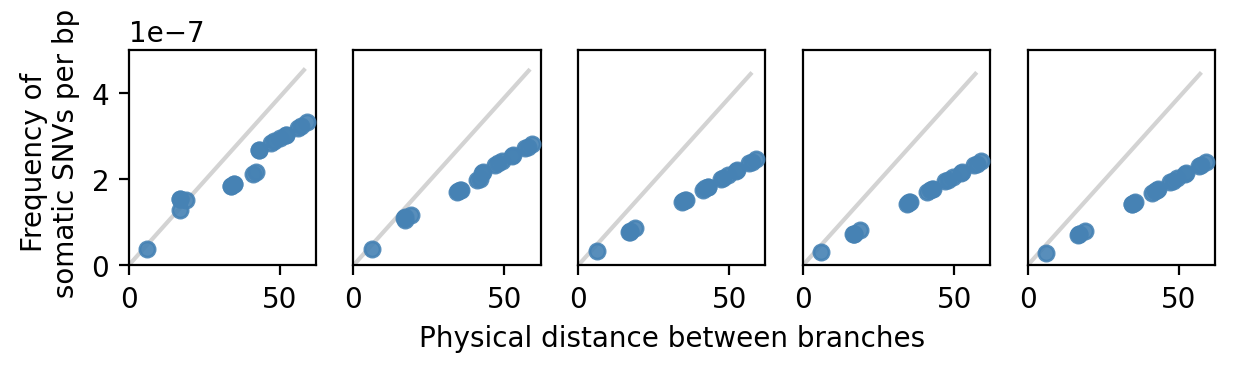

In [28]:
dyn = 4 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
    
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,5*10**(-7) )
            
    plt.show()

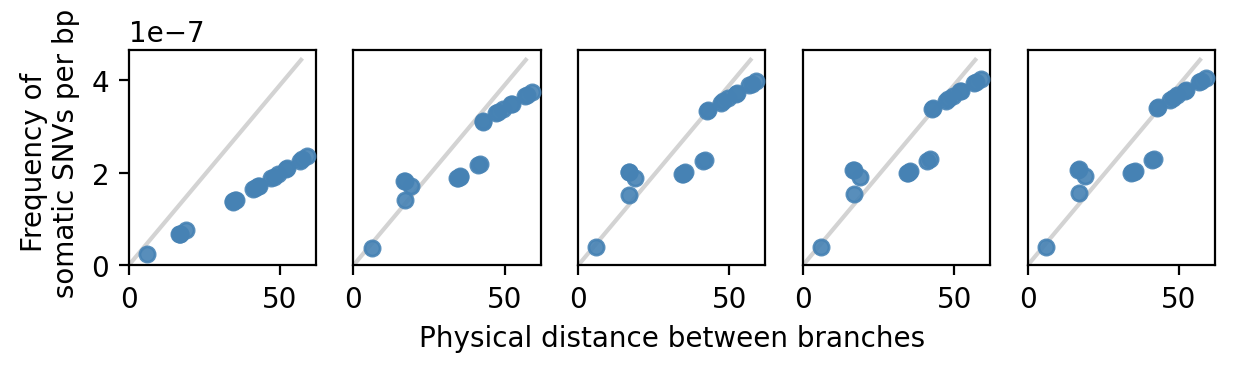

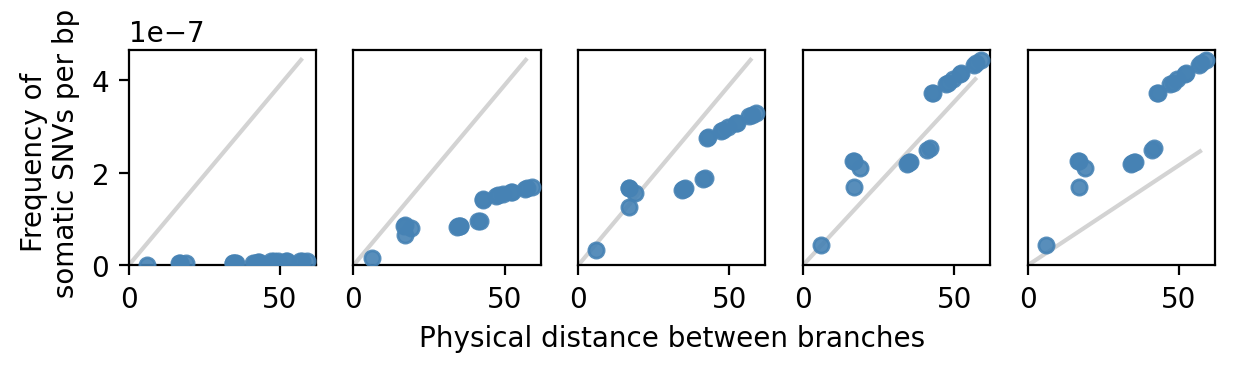

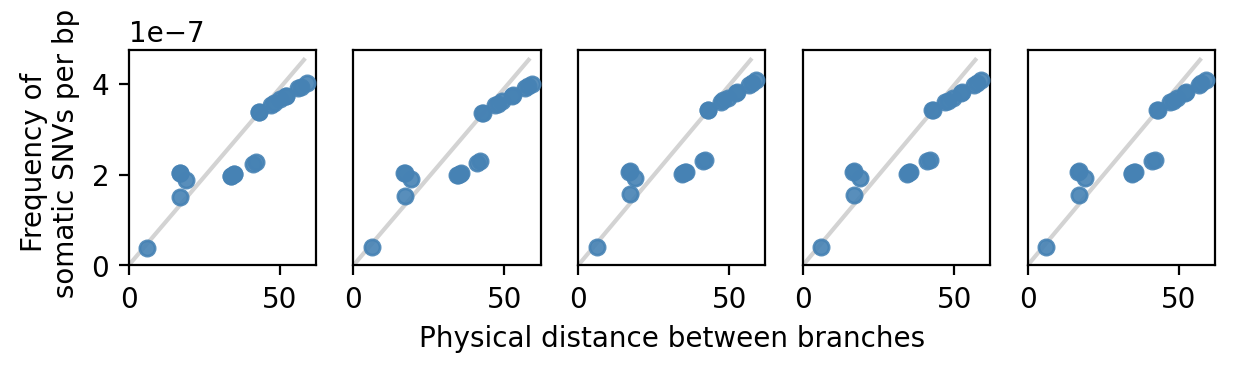

In [101]:
dyn = 2 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
    
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [17, 4.0e-09, 0, 0, 0, 17] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

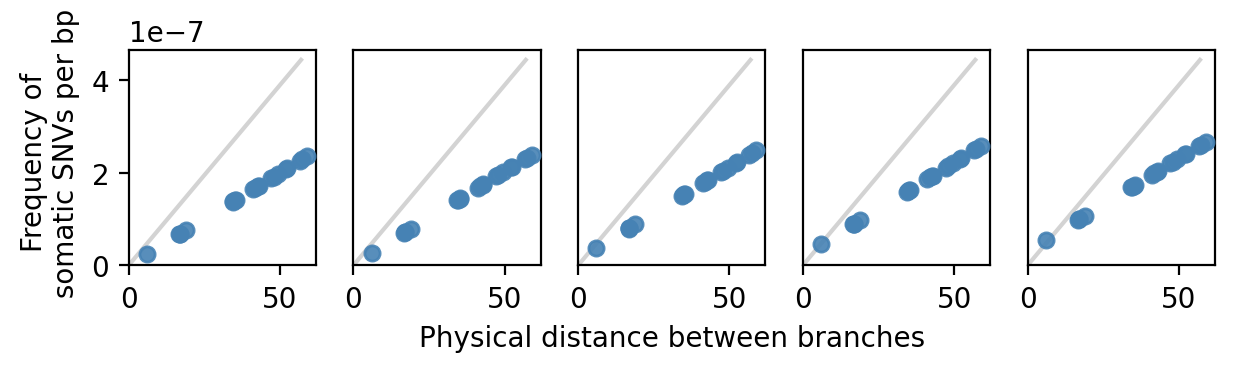

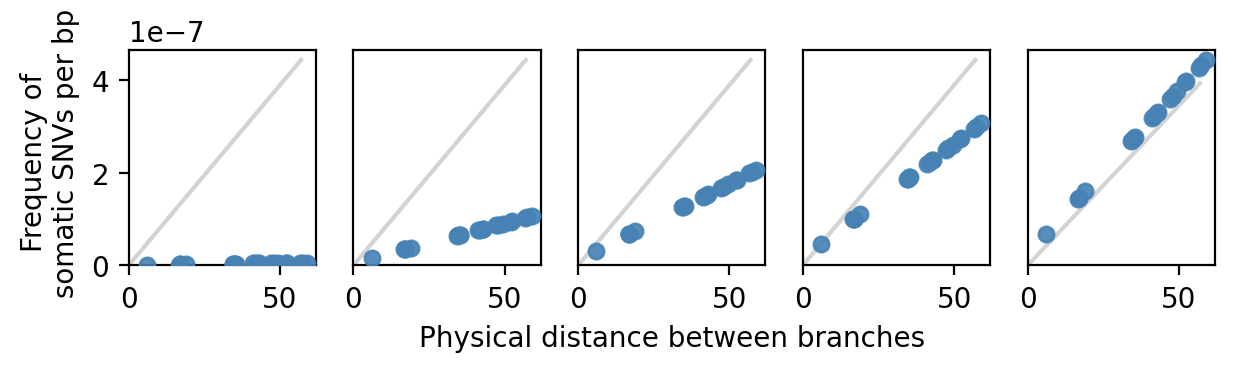

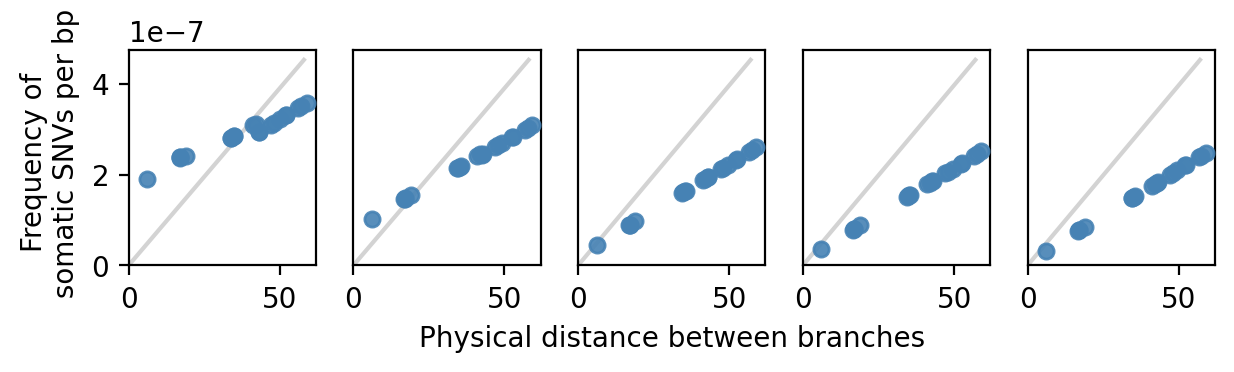

In [100]:
dyn = 3 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):

    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [17, 4.0e-09, 0, 0, 0, 17] # median of each parameter range
    
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

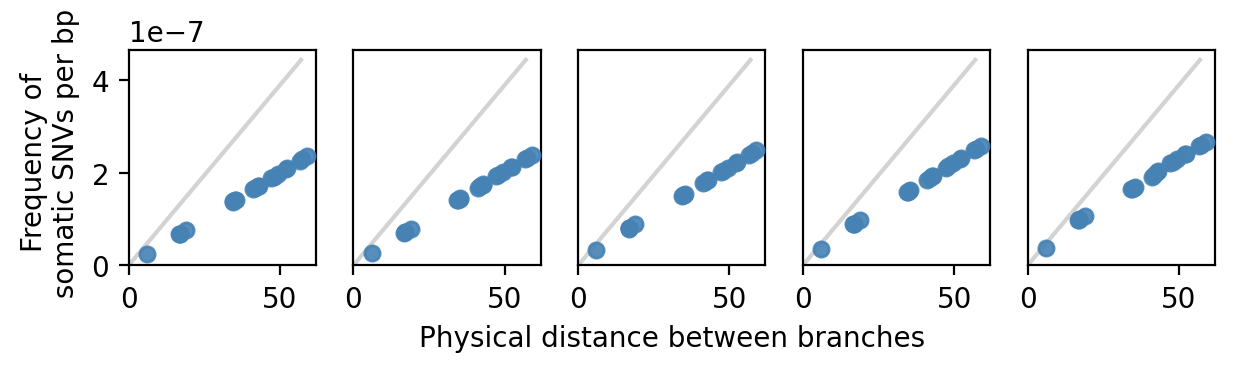

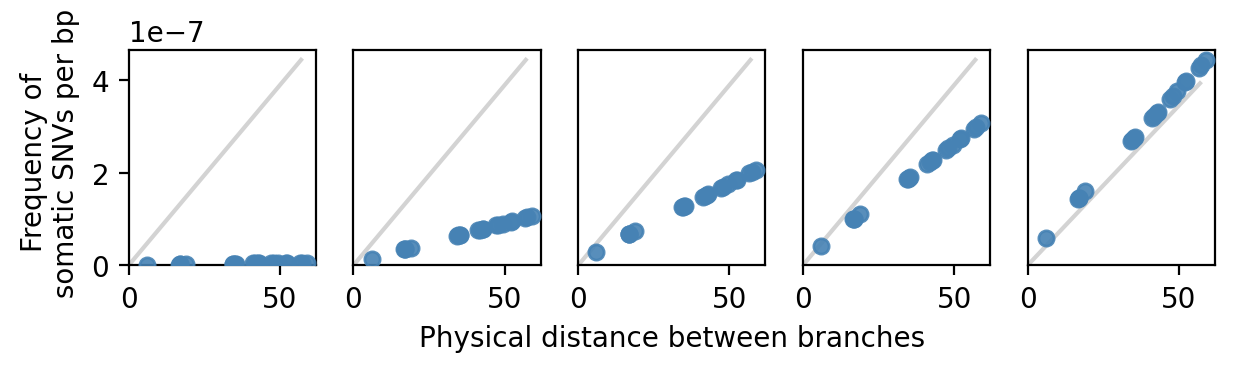

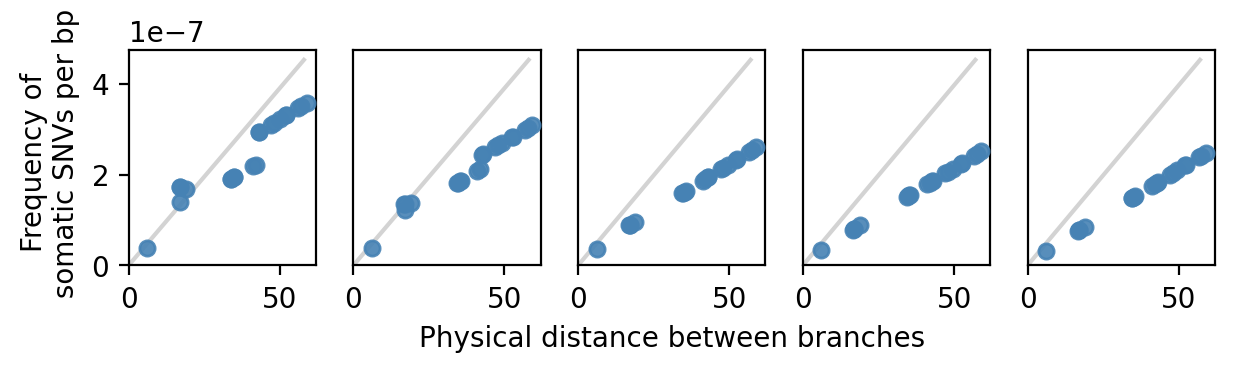

In [104]:
dyn = 4 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
 
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [17, 4.0e-09, 0, 0, 0, 17] # median of each parameter range
   
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c=colorlist[0], alpha=0.9, zorder=3)
    #     for icut, i in enumerate(is_ax): # for different point shape
    #         if i==0: # apical
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='v', c=colorlist[0], alpha=0.9, zorder=3) # zonder=layer
    #         else:
    #             plt.scatter(br_markov[icut], ibm_markov[icut], s=60, marker='o', c=colorlist[0], alpha=0.9, zorder=3)

        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='lightgrey', zorder=1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

### for Plots in figure

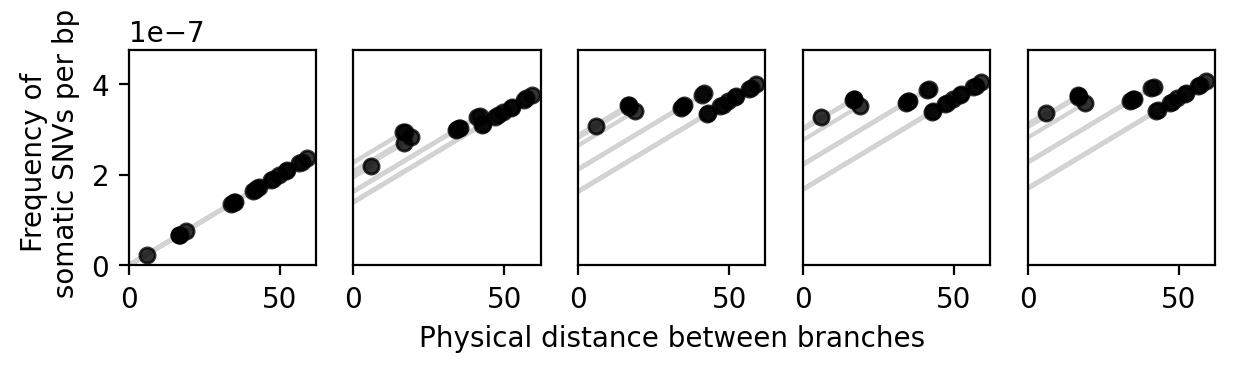

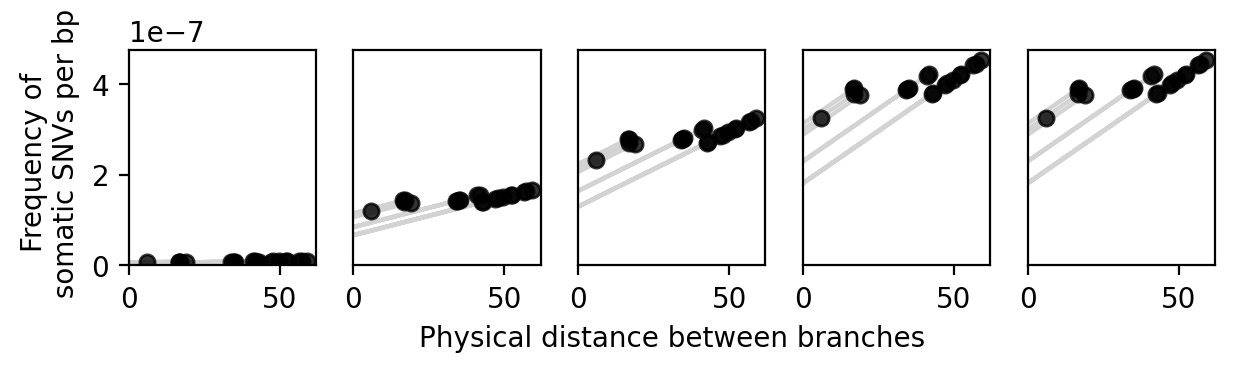

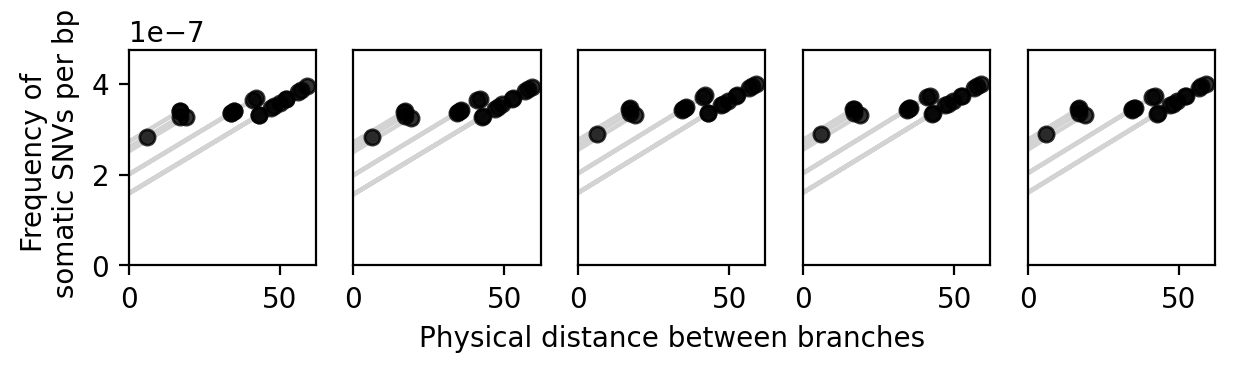

In [30]:
dyn = 1 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
 
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
   
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c='black', alpha=0.8, zorder=3)

        # Linear line plots
        for icut in range(len(br_markov)):
            slope = mut_S1
            x_p = br_markov[icut]
            y_p = ibm_markov[icut]
            line_x = [0, x_p]
            line_y = [slope*(x_-x_p) + y_p for x_ in line_x]
            plt.plot(line_x, line_y, c='lightgrey', zorder=1)
        
        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='white', zorder=-1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

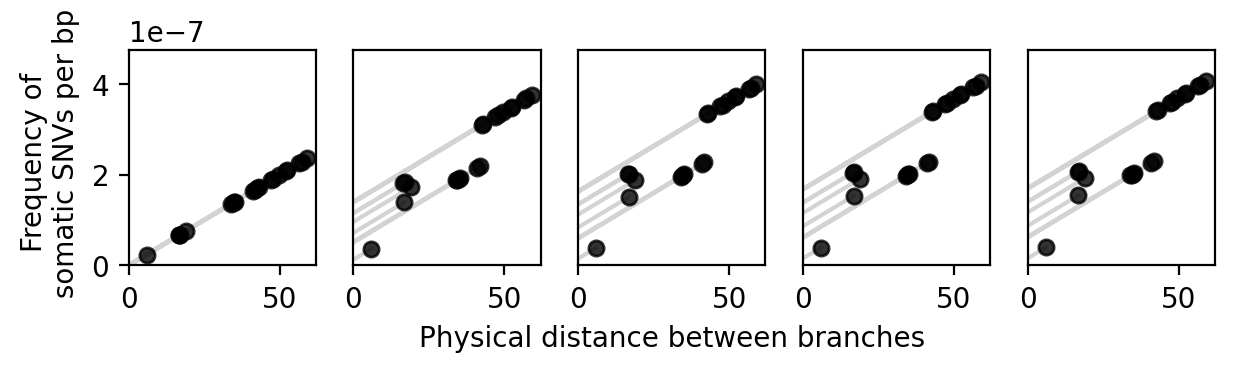

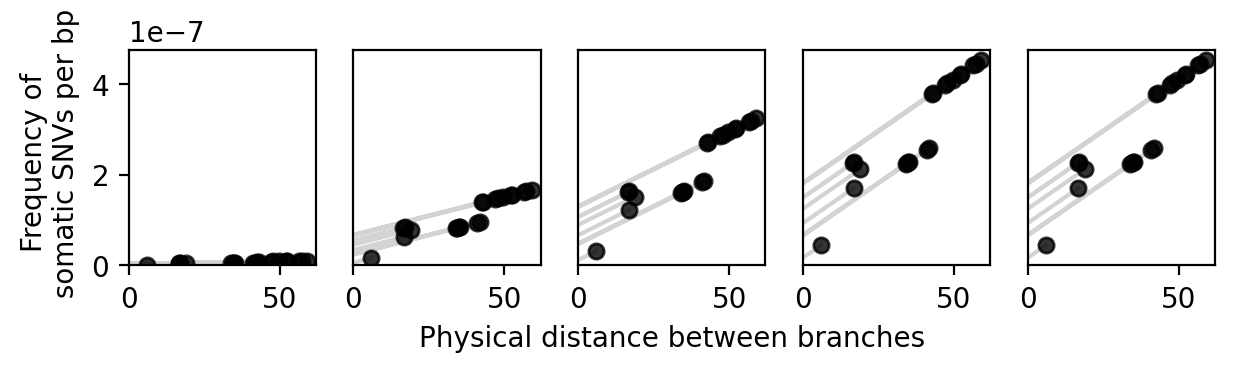

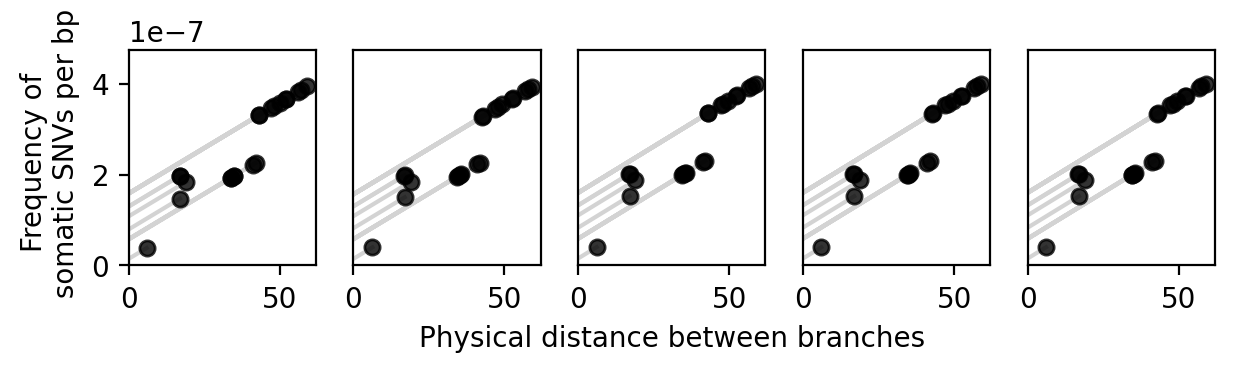

In [31]:
dyn = 2 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
 
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
   
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c='black', alpha=0.8, zorder=3)

        # Linear line plots
        for icut in range(len(br_markov)):
            slope = mut_S1
            x_p = br_markov[icut]
            y_p = ibm_markov[icut]
            line_x = [0, x_p]
            line_y = [slope*(x_-x_p) + y_p for x_ in line_x]
            plt.plot(line_x, line_y, c='lightgrey', zorder=1)
        
        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='white', zorder=-1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

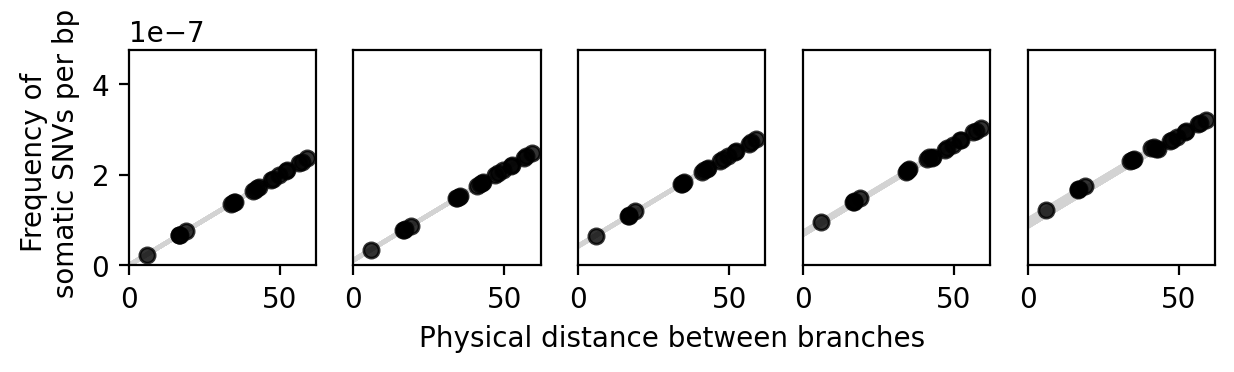

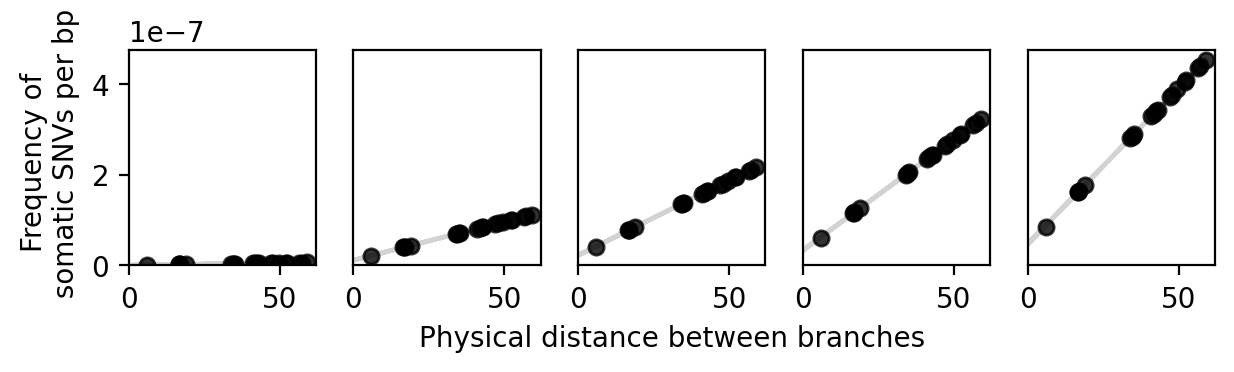

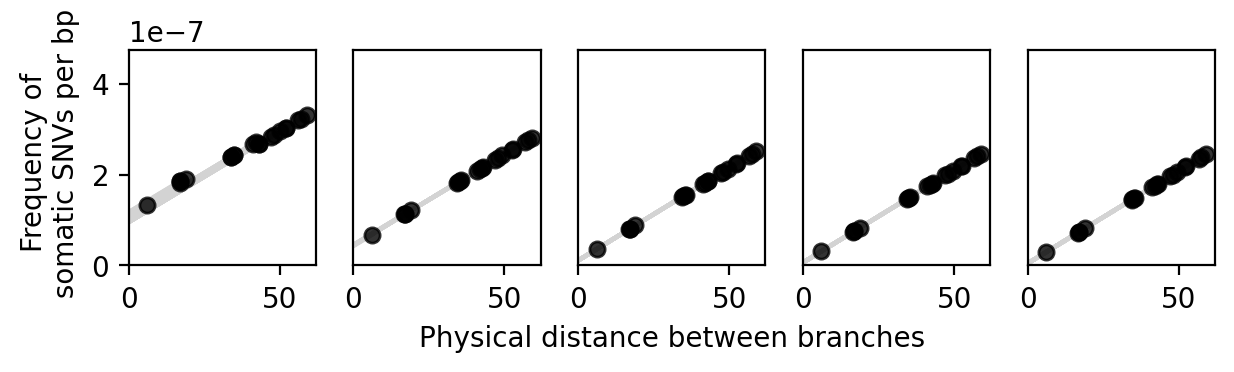

In [33]:
dyn = 3 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
 
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
   
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c='black', alpha=0.8, zorder=3)

        # Linear line plots
        for icut in range(len(br_markov)):
            slope = mut_S1
            x_p = br_markov[icut]
            y_p = ibm_markov[icut]
            line_x = [0, x_p]
            line_y = [slope*(x_-x_p) + y_p for x_ in line_x]
            plt.plot(line_x, line_y, c='lightgrey', zorder=1)
        
        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='white', zorder=-1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()

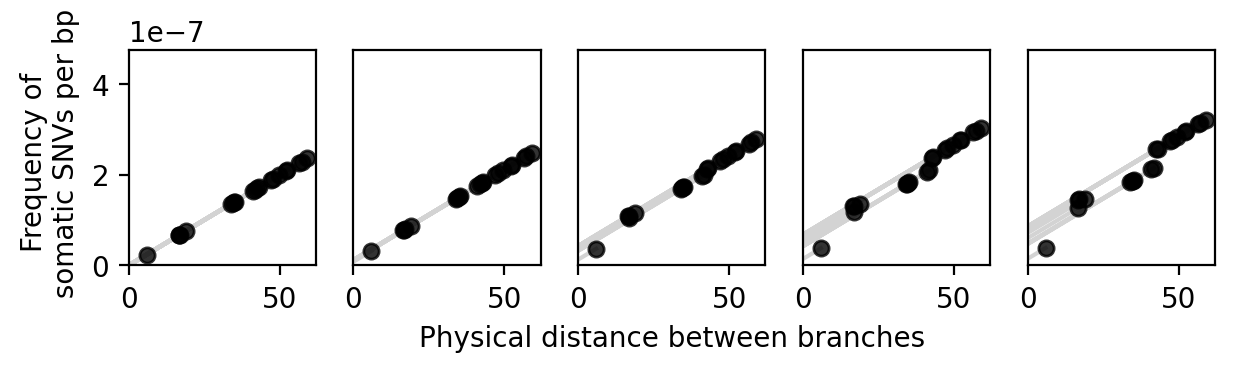

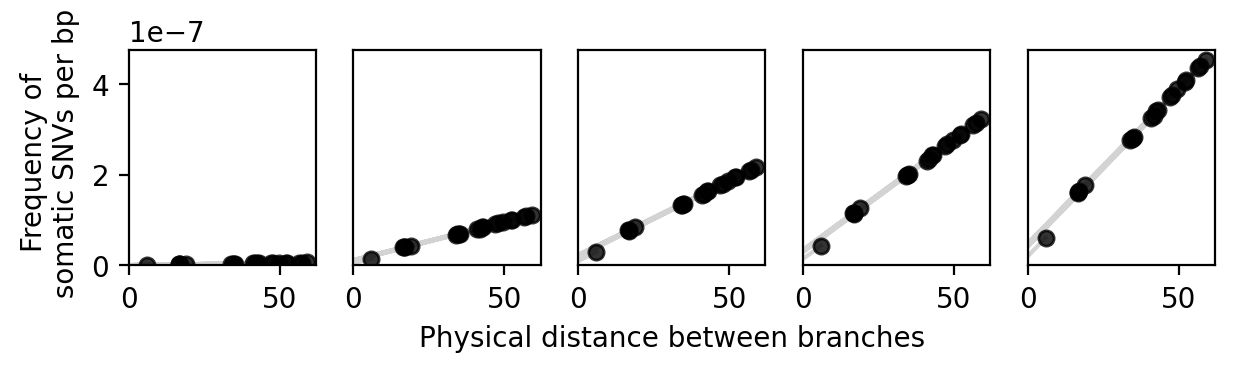

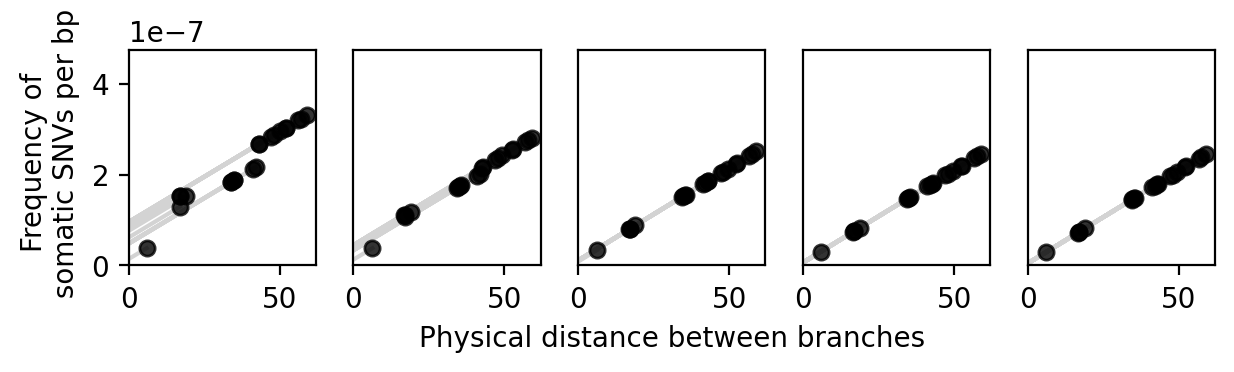

In [34]:
dyn = 4 # model ID

for ct_p, paraList in enumerate([num_stList, mutList, divList]):
 
    # non-focal parameters
    num_st, mut_S1, mut_S2, mut_F1, mut_F2, div = [10, 4.0e-09, 0, 0, 0, 5] # median of each parameter range
   
    fig, ax = plt.subplots(ncols=len(paraList), nrows=1, 
                       figsize=(2*3.50394, 0.4*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct, para_id in enumerate(paraList):

        # naming parameter index
        if ct_p == 0:
            num_st = para_id
        elif ct_p == 1:
            mut_S1= para_id
        elif ct_p == 2:
            div = para_id

        plt.subplot(1, len(paraList), ct+1)

        ind_list = [[mut_S1_Flat, mut_S1, br_len_S1],
                    [mut_S2_Flat, mut_S2, br_len_S2],
                    [mut_F1_Flat, mut_F1, br_len_F1],
                    [mut_F2_Flat, mut_F2, br_len_F2]]

        colorlist = ['steelblue', 'skyblue', 'red', 'orange']

        data_result = mut_S1_Flat

        markov_result = ibm_Markov(num_st, mut_S1, div, dyn, br_len_S1)
        ibm_markov, br_markov, is_ax = markov_result

        # scatter plots
        plt.scatter(br_markov, ibm_markov, s=30, marker='o', c='black', alpha=0.8, zorder=3)

        # Linear line plots
        for icut in range(len(br_markov)):
            slope = mut_S1
            x_p = br_markov[icut]
            y_p = ibm_markov[icut]
            line_x = [0, x_p]
            line_y = [slope*(x_-x_p) + y_p for x_ in line_x]
            plt.plot(line_x, line_y, c='lightgrey', zorder=1)
        
        # line plots
        x_list = np.array([i for i in range(int(max(br_markov)))])
        plt.plot(x_list, reg_0(br_markov, data_result) * x_list, c='white', zorder=-1)

        # axises
        if ct==0:
            plt.xlabel('',fontsize=10)
            plt.ylabel('Frequency of \n somatic SNVs per bp',fontsize=10)
        elif ct == 2:
            plt.xlabel('Physical distance between branches',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])
        else:
            plt.xlabel('',fontsize=10)
            plt.ylabel('',fontsize=10)
            plt.yticks([])

        plt.xlim(0,); plt.ylim(0,)

    plt.show()